<a href="https://colab.research.google.com/github/atharva7279/my_deeplearning/blob/main/Untitled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building a neural netwrok


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class Model(nn.Module):
  # Input layer(4 features of flower)
  # Hidden layer 1
  # Hidden layer 2
  # Ouput layer ( 3 classes of flower)
  def __init__(self , in_features = 4 , h1=8 , h2=9 , out_features = 3):
    super().__init__()
    self.fc1 = nn.Linear(in_features , h1)
    self.fc2 = nn.Linear(h1 , h2)
    self.out = nn.Linear(h2 , out_features)

  def forward(self , x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x

In [34]:
# Pick a manual seed for randomization
torch.manual_seed(41)
# Create an instance of model
model = Model()


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

Loading data

In [ ]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
data = pd.read_csv(url)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
data['species'] = data['species'].replace('setosa' , 0.0)
data['species'] = data['species'].replace('versicolor' , 1.0)
data['species'] = data['species'].replace('virginica' , 2.0)

/tmp/ipykernel_12775/4266993494.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['species'] = data['species'].replace('virginica' , 2.0)


In [ ]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [ ]:
# Train Test Split
X = data.drop('species' , axis = 1)
y = data['species']

In [ ]:
# Converting to numpy array
X = X.values
y = y.values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Train Test Split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 41)

In [ ]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [41]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr = 0.1)

In [42]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [46]:
# model training
# epoch -> one run though the training data in our network
epochs = 100

losses = []
for i in range(epochs):
  y_pred = model.forward(X_train)

  loss = criterion(y_pred , y_train)

  losses.append(loss.detach().numpy())

  if i%10 == 0:
    print(f'Epoch {i} loss is {loss}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch 0 loss is 0.0005094486405141652
Epoch 10 loss is 0.0004985116538591683
Epoch 20 loss is 0.00048791756853461266
Epoch 30 loss is 0.00047760820598341525
Epoch 40 loss is 0.00046760629629716277
Epoch 50 loss is 0.00045791312004439533
Epoch 60 loss is 0.0004485089739318937
Epoch 70 loss is 0.00043939033639617264
Epoch 80 loss is 0.0004305188776925206
Epoch 90 loss is 0.00042194020352326334


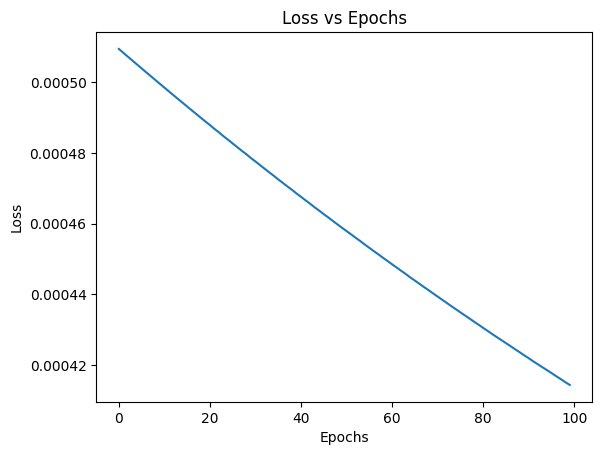

In [51]:
plt.plot(range(epochs) , losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

In [50]:
with torch.no_grad(): # turn off back propagation
  y_pred = model.forward(X_test)
  loss = criterion(y_pred , y_test)
  print(loss)

tensor(0.8122)


In [54]:
correct = 0
with torch.no_grad():
  for i,data in enumerate(X_test):
    y_val = model.forward(data)

    print(f'{i+1}.) {str(y_val)} \t {y_test[i]}')

    #correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1
print(correct)

1.) tensor([-50.7568,  -3.6566,  21.6473]) 	 2
2.) tensor([-72.9923, -25.4604,  59.5686]) 	 2
3.) tensor([-81.6130, -26.5145,  64.6865]) 	 2
4.) tensor([-34.5252,   9.2508,  -2.6037]) 	 1
5.) tensor([-66.7787, -14.7208,  42.9306]) 	 2
6.) tensor([-29.1573,   7.6547,  -2.8360]) 	 1
7.) tensor([-51.5120,  -0.6541,  18.0650]) 	 2
8.) tensor([-35.1377,   9.4329,  -2.5772]) 	 1
9.) tensor([-58.8527,  -7.2007,  29.7287]) 	 2
10.) tensor([-78.0874, -27.7058,  64.6722]) 	 2
11.) tensor([-47.4889,   3.5925,  10.7792]) 	 2
12.) tensor([ 5.7045, -2.7109, -4.3449]) 	 0
13.) tensor([ 5.7045, -2.7109, -4.3449]) 	 0
14.) tensor([-20.8494,   5.1845,  -3.1956]) 	 1
15.) tensor([ 3.5771, -2.0783, -4.2528]) 	 0
16.) tensor([-42.0973,   9.9107,   0.1731]) 	 2
17.) tensor([ 5.7045, -2.7109, -4.3449]) 	 0
18.) tensor([-48.4201,   0.5358,  15.1545]) 	 1
19.) tensor([ 5.7045, -2.7109, -4.3449]) 	 0
20.) tensor([ 5.1938, -2.5590, -4.3228]) 	 0
21.) tensor([-23.6769,   6.0252,  -3.0732]) 	 1
22.) tensor([-74.30

Evaluating new data

In [59]:
new_iris = torch.tensor([4.7, 3.2, 1.3 , 0.2])

In [60]:
with torch.no_grad():
  print(model(new_iris))

tensor([ 5.7045, -2.7109, -4.3449])


save and load model

In [61]:
torch.save(model.state_dict(), 'my_second_model.pt')

In [63]:
# load the saved model
new_model = Model()
new_model.load_state_dict(torch.load('my_second_model.pt'))


<All keys matched successfully>

In [64]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)